In [3]:
# importing libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn import neighbors
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
import math
import os

In [4]:
data=pd.read_csv("breast_cancer_dataset.csv")
data

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [5]:
class_labels=data['diagnosis']
ids=data['id']
print(data["diagnosis"].value_counts())
data=data.drop(['id','diagnosis'],axis=1)
colnames=list(data.columns)
colnames
print(data)
print(colnames)


diagnosis
B    357
M    212
Name: count, dtype: int64
     radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0          17.99         10.38          122.80     1001.0          0.11840   
1          20.57         17.77          132.90     1326.0          0.08474   
2          19.69         21.25          130.00     1203.0          0.10960   
3          11.42         20.38           77.58      386.1          0.14250   
4          20.29         14.34          135.10     1297.0          0.10030   
..           ...           ...             ...        ...              ...   
564        21.56         22.39          142.00     1479.0          0.11100   
565        20.13         28.25          131.20     1261.0          0.09780   
566        16.60         28.08          108.30      858.1          0.08455   
567        20.60         29.33          140.10     1265.0          0.11780   
568         7.76         24.54           47.92      181.0          0.05263   

     comp

In [6]:
scale = StandardScaler()
scaled_data = scale.fit_transform(data)
df = pd.DataFrame(scaled_data, columns = colnames)
df

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,2.110995,0.721473,2.060786,2.343856,1.041842,0.219060,1.947285,2.320965,-0.312589,-0.931027,...,1.901185,0.117700,1.752563,2.015301,0.378365,-0.273318,0.664512,1.629151,-1.360158,-0.709091
565,1.704854,2.085134,1.615931,1.723842,0.102458,-0.017833,0.693043,1.263669,-0.217664,-1.058611,...,1.536720,2.047399,1.421940,1.494959,-0.691230,-0.394820,0.236573,0.733827,-0.531855,-0.973978
566,0.702284,2.045574,0.672676,0.577953,-0.840484,-0.038680,0.046588,0.105777,-0.809117,-0.895587,...,0.561361,1.374854,0.579001,0.427906,-0.809587,0.350735,0.326767,0.414069,-1.104549,-0.318409
567,1.838341,2.336457,1.982524,1.735218,1.525767,3.272144,3.296944,2.658866,2.137194,1.043695,...,1.961239,2.237926,2.303601,1.653171,1.430427,3.904848,3.197605,2.289985,1.919083,2.219635


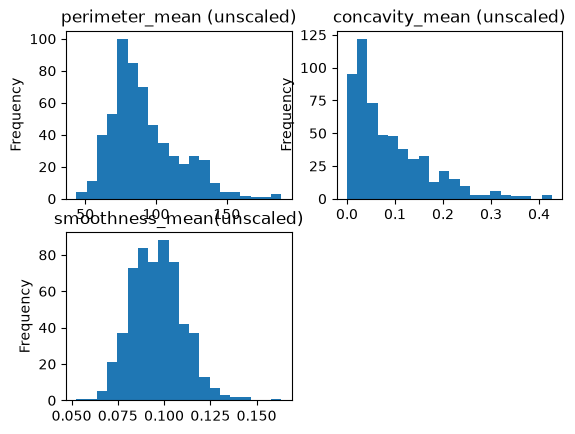

In [7]:
#array_list=np.array([data["compactness_mean"].to_numpy(),data["perimeter_mean"].to_numpy(),data["concavity_worst"].to_numpy()])
#print(array_list)

# Plot
plt.subplot(2,2,1)
plt.hist(data["perimeter_mean"], 20, histtype='bar')
plt.gca().set(title='perimeter_mean (unscaled)', ylabel='Frequency');

plt.subplot(2,2,2)
plt.hist(data["concavity_mean"], 20, histtype='bar')
plt.gca().set(title='concavity_mean (unscaled)', ylabel='Frequency');

plt.subplot(2,2,3)
plt.hist(data["smoothness_mean"], 20, histtype='bar')
plt.gca().set(title='smoothness_mean(unscaled)', ylabel='Frequency');

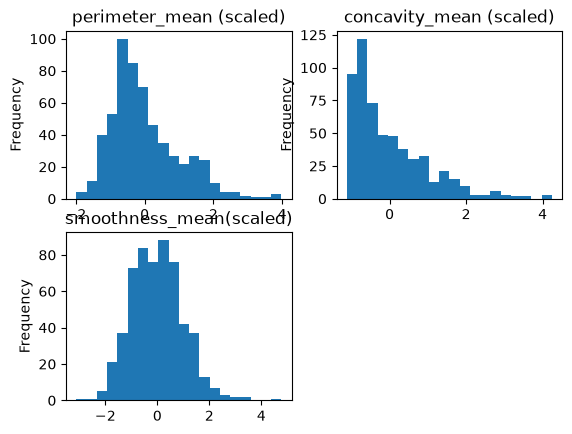

In [8]:
# Plot
plt.subplot(2,2,1)
plt.hist(df["perimeter_mean"], 20, histtype='bar')
plt.gca().set(title='perimeter_mean (scaled)', ylabel='Frequency');

plt.subplot(2,2,2)
plt.hist(df["concavity_mean"], 20, histtype='bar')
plt.gca().set(title='concavity_mean (scaled)', ylabel='Frequency');

plt.subplot(2,2,3)
plt.hist(df["smoothness_mean"], 20, histtype='bar')
plt.gca().set(title='smoothness_mean(scaled)', ylabel='Frequency');

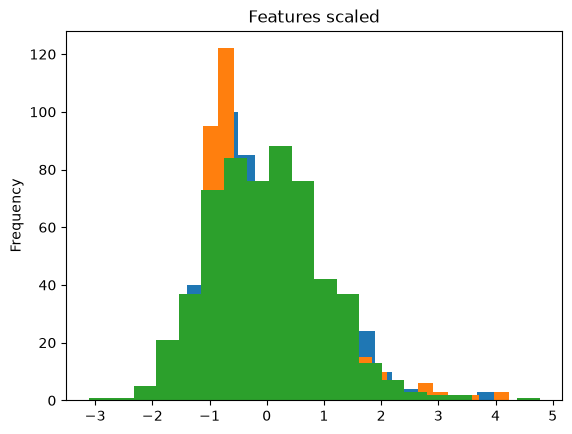

In [9]:
# Plot
plt.hist(df["perimeter_mean"], 20, histtype='bar')
plt.hist(df["concavity_mean"], 20, histtype='bar')
plt.hist(df["smoothness_mean"], 20, histtype='bar')
plt.gca().set(title='Features scaled', ylabel='Frequency');

In [10]:
correl=data.corr()
print(correl.head(3))
print("The feature dimensions being correlated are:",correl.shape)

                radius_mean  texture_mean  perimeter_mean  area_mean  \
radius_mean        1.000000      0.323782        0.997855   0.987357   
texture_mean       0.323782      1.000000        0.329533   0.321086   
perimeter_mean     0.997855      0.329533        1.000000   0.986507   

                smoothness_mean  compactness_mean  concavity_mean  \
radius_mean            0.170581          0.506124        0.676764   
texture_mean          -0.023389          0.236702        0.302418   
perimeter_mean         0.207278          0.556936        0.716136   

                concave points_mean  symmetry_mean  fractal_dimension_mean  \
radius_mean                0.822529       0.147741               -0.311631   
texture_mean               0.293464       0.071401               -0.076437   
perimeter_mean             0.850977       0.183027               -0.261477   

                ...  radius_worst  texture_worst  perimeter_worst  area_worst  \
radius_mean     ...      0.969539       

In [11]:
correl_array=correl.to_numpy().copy()
ind = np.diag_indices_from(correl_array)
correl_array[ind]=0
correl_array=pd.DataFrame(correl_array,columns=colnames,index=colnames)
#correl_array

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


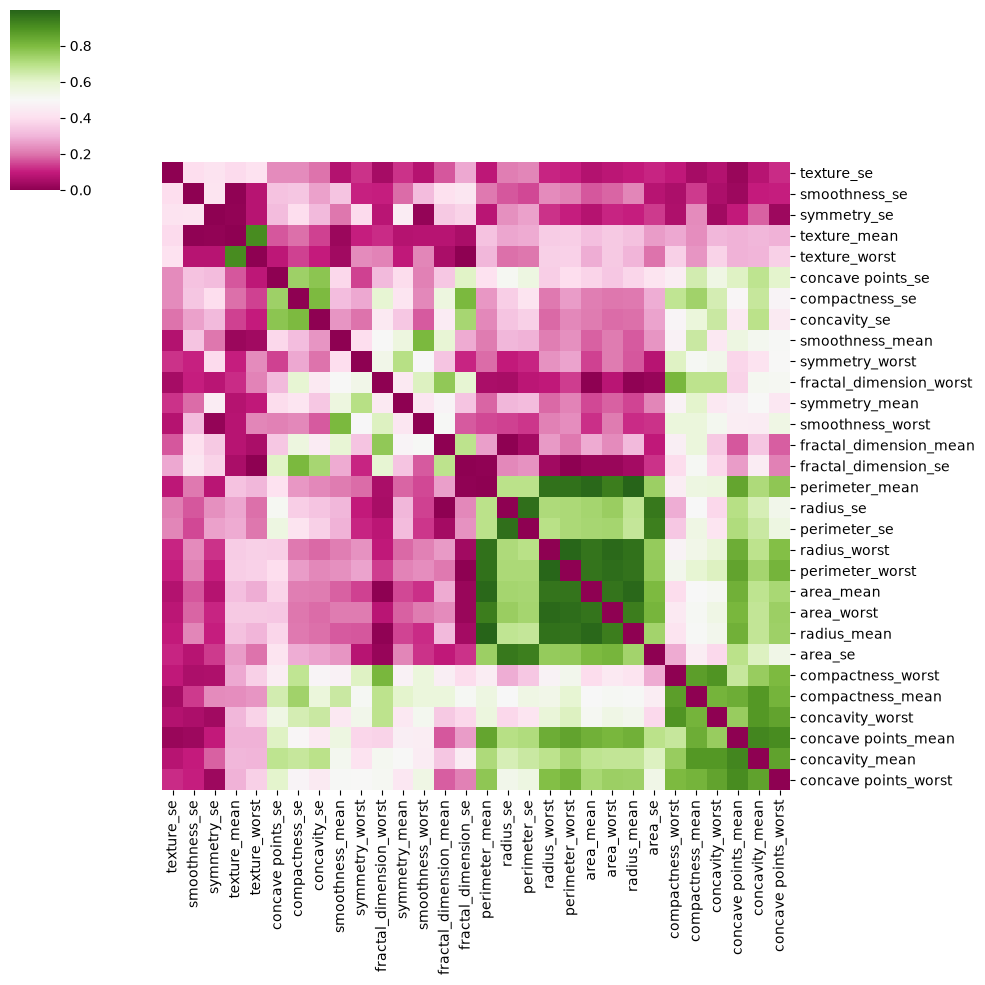

In [12]:
dataplot=sns.clustermap(abs(correl_array),cmap="PiYG",standard_scale=None,method='complete')
dataplot.ax_row_dendrogram.set_visible(False)
dataplot.ax_col_dendrogram.set_visible(False) 
# displaying heatmap
plt.show()

In [13]:
avg_correl=abs(correl_array).mean(axis=1)
#print(avg_correl)
indarr=np.where(avg_correl<0.35)
selectedFeatures=avg_correl.iloc[indarr]
selFeatList=(selectedFeatures.index).tolist()
print(selFeatList)
df2=df[selFeatList]
colnames2=list(df2.columns)
#df2.shape


['texture_mean', 'smoothness_mean', 'symmetry_mean', 'fractal_dimension_mean', 'texture_se', 'smoothness_se', 'symmetry_se', 'fractal_dimension_se', 'texture_worst', 'smoothness_worst', 'symmetry_worst', 'fractal_dimension_worst']


                         texture_mean  smoothness_mean  symmetry_mean  \
texture_mean                 0.000000        -0.023389       0.071401   
smoothness_mean             -0.023389         0.000000       0.557775   
symmetry_mean                0.071401         0.557775       0.000000   
fractal_dimension_mean      -0.076437         0.584792       0.479921   
texture_se                   0.386358         0.068406       0.128053   
smoothness_se                0.006614         0.332375       0.187321   
symmetry_se                  0.009127         0.200774       0.449137   
fractal_dimension_se         0.054458         0.283607       0.331786   
texture_worst                0.912045         0.036072       0.090651   
smoothness_worst             0.077503         0.805324       0.426675   
symmetry_worst               0.105008         0.394309       0.699826   
fractal_dimension_worst      0.119205         0.499316       0.438413   

                         fractal_dimension_mean  t

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


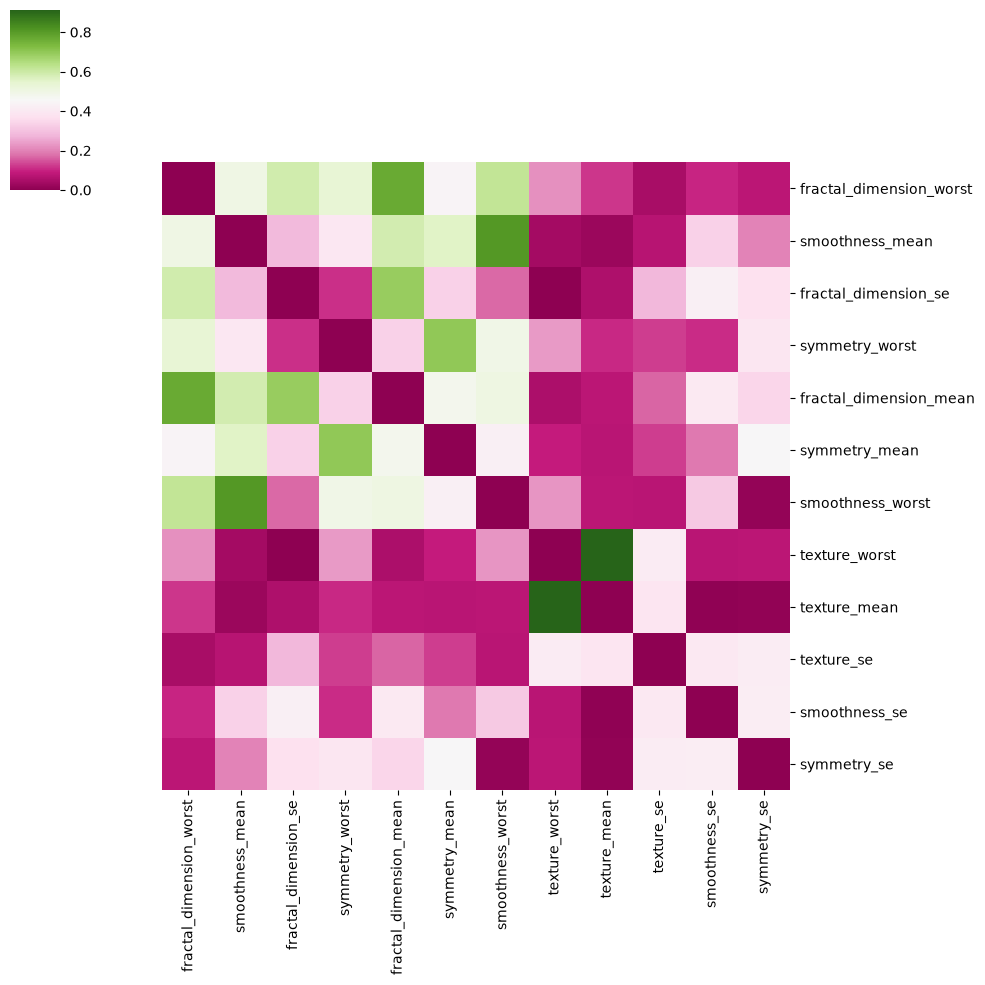

In [14]:
correl_array2= pd.DataFrame(correl_array,index=selFeatList,columns=selFeatList)
print(correl_array2)
dataplot=sns.clustermap(abs(correl_array2),cmap="PiYG",standard_scale=None,method='complete')
dataplot.ax_row_dendrogram.set_visible(False)
dataplot.ax_col_dendrogram.set_visible(False) 
# displaying heatmap
plt.show()

In [15]:
X=df2.to_numpy()
y=class_labels
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 30,test_size=0.3)
print(X_train.shape[0])
print((X_train.shape[0]/X.shape[0])*100)
#X_test

398
69.94727592267135


In [16]:
n_neighbors=3
knn3 = neighbors.KNeighborsClassifier(n_neighbors, weights='distance',metric='minkowski')
knn3.fit(X_train, y_train)

n_neighbors=7
knn7= neighbors.KNeighborsClassifier(n_neighbors, weights='distance',metric='minkowski')
knn7.fit(X_train, y_train)

n_neighbors=10
knn10= neighbors.KNeighborsClassifier(n_neighbors, weights='distance',metric='minkowski')
knn10.fit(X_train, y_train)

y_pred_3 = knn3.predict(X_test)
y_pred_7 = knn7.predict(X_test)
y_pred_10 = knn10.predict(X_test)

#y_pred_10

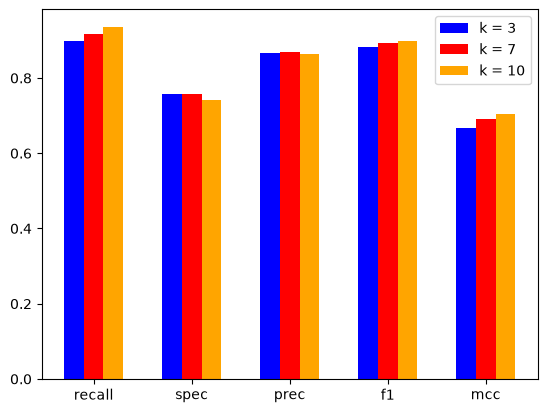

In [17]:
def mymetrics(pred_y,y_test_ref,class1,class2):
    TPctr=0
    FPctr=0
    TNctr=0
    FNctr=0
    for i in range(0,len(pred_y)):
        #print(i)
        if y_test_ref[i]==class1 and pred_y[i]==class1:
            TPctr=TPctr+1
        elif y_test_ref[i]==class1 and pred_y[i]==class2:
            FNctr=FNctr+1
        elif y_test_ref[i]==class2 and pred_y[i]==class2:
            TNctr=TNctr+1
        else:
            FPctr=FPctr+1

    classes=[class1,class2]
    CM=pd.DataFrame([[TPctr,FNctr],[TNctr,FPctr]],columns=classes,index=classes)
    recall=TPctr/(TPctr+FNctr)
    spec=TNctr/(TNctr+FPctr)
    prec=TPctr/(TPctr+FPctr)
    f1_score=2*prec*recall/(prec+recall)
    mcc=((TPctr*TNctr)-(FPctr*FNctr))/math.sqrt(((TPctr+FPctr)*(TNctr+FPctr)*(TPctr+FNctr)*(TNctr+FNctr)))
    return(CM,recall,spec,prec,f1_score,mcc)


class1="B"
class2="M"
y_test_ref=y_test.to_numpy()

pred_y=y_pred_3
CM1, recall1, spec1, prec1, f11, mcc1=mymetrics(pred_y,y_test_ref,class1,class2)

pred_y=y_pred_7
CM2, recall2, spec2, prec2, f12, mcc2=mymetrics(pred_y,y_test_ref,class1,class2)

pred_y=y_pred_10
CM3, recall3, spec3, prec3, f13, mcc3=mymetrics(pred_y,y_test_ref,class1,class2)

xax=np.arange(5)
plt.bar(xax-0.2,[recall1, spec1, prec1, f11, mcc1],width=0.2,color="blue")
plt.bar(xax,[recall2, spec2, prec2, f12, mcc2],width=0.2,color="red")
plt.bar(xax+0.2,[recall3, spec3, prec3, f13, mcc3],width=0.2,color="orange")

plt.xticks(xax, ["recall", "spec", "prec", "f1", "mcc"])
plt.legend(["k = 3", "k = 7","k = 10"])
plt.show()

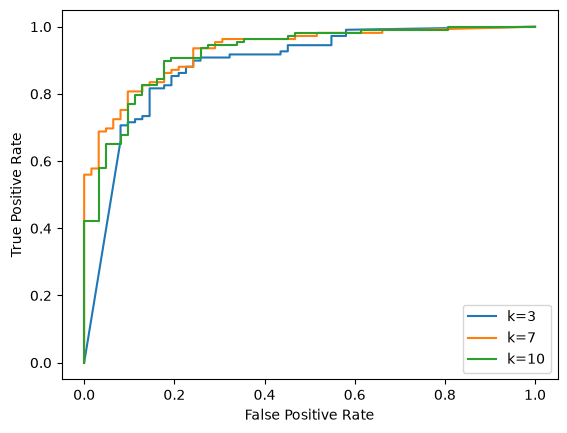

0.9217224030778337

In [18]:
probs3=knn3.predict_proba(X_test)
probs7=knn7.predict_proba(X_test)
probs10=knn10.predict_proba(X_test)
#print(probs)
#print(probs3.shape)
fpr, tpr, thresholds = roc_curve(y_test, probs3[:,0],pos_label="B")
plt.plot(fpr, tpr)
fpr, tpr, thresholds = roc_curve(y_test, probs7[:,0],pos_label="B")
plt.plot(fpr, tpr)
fpr, tpr, thresholds = roc_curve(y_test, probs10[:,0],pos_label="B")
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(['k=3','k=7','k=10'])
plt.show()
auc(fpr, tpr)

# q1 Modify the given script (Dataset_script_template folder) to compare the following four feature selection / dimensionality reduction techniques

In [19]:
# Filter-based method: Information Gain

In [20]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

In [21]:
df = pd.read_csv('breast_cancer_dataset.csv')

In [22]:
X = df.drop(columns=['id', 'diagnosis'], errors='ignore')
y = df['diagnosis']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

In [24]:
k_best_features = 10
selector = SelectKBest(score_func=mutual_info_classif, k=k_best_features)

In [25]:
X_train_ig = selector.fit_transform(X_train, y_train)
X_test_ig = selector.transform(X_test)

In [26]:
selected_features = X.columns[selector.get_support()].tolist()

In [27]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_ig)
X_test_scaled = scaler.transform(X_test_ig)

In [28]:
from sklearn.neighbors import KNeighborsClassifier

In [29]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](2,)","['B','M']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [30]:
y_pred = knn.predict(X_test_scaled)

In [31]:
print(f"Selected Top {k_best_features} Features:")
print(selected_features)

Selected Top 10 Features:
['radius_mean', 'perimeter_mean', 'area_mean', 'concavity_mean', 'concave points_mean', 'area_se', 'radius_worst', 'perimeter_worst', 'area_worst', 'concave points_worst']


In [32]:
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix, classification_report

In [33]:
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred, pos_label='M')
f1 = f1_score(y_test, y_pred, pos_label='M')
cm = confusion_matrix(y_test, y_pred)

In [53]:
print(f"Accuracy: {accuracy:.4f}")
print(f"Recall (Malignant): {recall:.4f}")
print(f"F1-Score (Malignant): {f1:.4f}\n")

print("Confusion Matrix:")
print(cm)

print("\nFull Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9474
Recall (Malignant): 0.8906
F1-Score (Malignant): 0.9268

Confusion Matrix:
[[105   2]
 [  7  57]]

Full Classification Report:
              precision    recall  f1-score   support

           B       0.94      0.98      0.96       107
           M       0.97      0.89      0.93        64

    accuracy                           0.95       171
   macro avg       0.95      0.94      0.94       171
weighted avg       0.95      0.95      0.95       171



In [85]:
mi_scores = mutual_info_classif(X_train, y_train, random_state=30)
mi_series = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=True)

In [88]:
colors = ['#1f77b4' if feat not in selected_features else '#ff7f0e' for feat in mi_series.index]

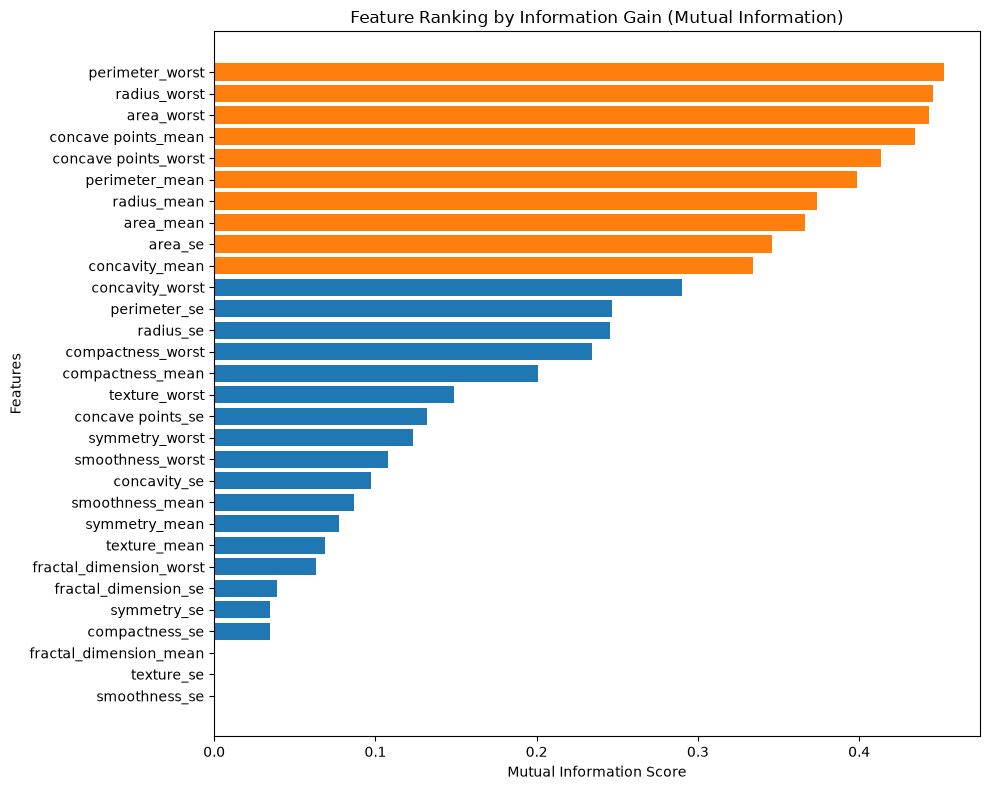

In [89]:
plt.figure(figsize=(10, 8))
plt.barh(mi_series.index, mi_series.values,color=colors)
plt.title('Feature Ranking by Information Gain (Mutual Information)')
plt.xlabel('Mutual Information Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [124]:
# Wrapper method: Backward elimination

In [2]:
from sklearn.feature_selection import SequentialFeatureSelector

In [59]:
knn = KNeighborsClassifier(n_neighbors=3)

In [60]:
sfs_backward = SequentialFeatureSelector(
    estimator=knn, 
    n_features_to_select=10, 
    direction='backward', 
    scoring='accuracy', 
    cv=5, 
    n_jobs=-1
)

In [1]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

NameError: name 'StandardScaler' is not defined

In [64]:
X_train_sfs = sfs_backward.fit_transform(X_train_scaled, y_train)
X_test_sfs = sfs_backward.transform(X_test_scaled)

In [65]:
selected_features_be = X.columns[sfs_backward.get_support()].tolist()

In [66]:
knn.fit(X_train_sfs, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](2,)","['B','M']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [67]:
y_pred = knn.predict(X_test_sfs)

In [68]:
print("Selected Top 10 Features (Backward Elimination):")
print(selected_features_be)

Selected Top 10 Features (Backward Elimination):
['texture_mean', 'concavity_mean', 'texture_se', 'smoothness_se', 'compactness_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst']


In [69]:
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Recall (Malignant): {recall_score(y_test, y_pred, pos_label='M'):.4f}")
print(f"F1-Score (Malignant): {f1_score(y_test, y_pred, pos_label='M'):.4f}\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nFull Classification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.9532
Recall (Malignant): 0.8750
F1-Score (Malignant): 0.9333

Confusion Matrix:
[[107   0]
 [  8  56]]

Full Classification Report:
              precision    recall  f1-score   support

           B       0.93      1.00      0.96       107
           M       1.00      0.88      0.93        64

    accuracy                           0.95       171
   macro avg       0.97      0.94      0.95       171
weighted avg       0.96      0.95      0.95       171



In [99]:
be_status = pd.Series(
    [1 if feat in selected_features_be else 0 for feat in X.columns],
    index=X.columnscolors = ['#1f77b4' if status == 0 else '#ff7f0e' for status in be_status.values]
).sort_values(ascending=True)

In [100]:
colors = ['#1f77b4' if status == 0 else '#ff7f0e' for status in be_status.values]

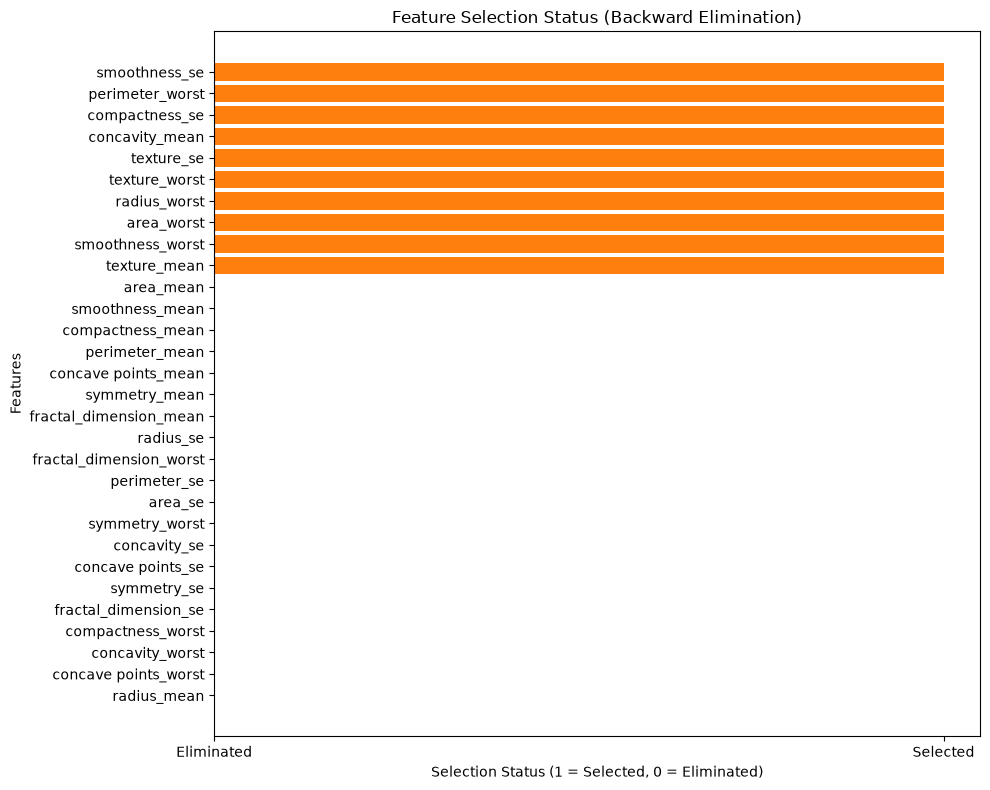

In [101]:
plt.figure(figsize=(10, 8))
plt.barh(be_status.index, be_status.values, color=colors)
plt.title('Feature Selection Status (Backward Elimination)')
plt.xlabel('Selection Status (1 = Selected, 0 = Eliminated)')
plt.ylabel('Features')
plt.xticks([0, 1], ['Eliminated', 'Selected'])
plt.tight_layout()
plt.show()

In [1]:
# Recursive feature elimination (SVM-RFE)

In [2]:
from sklearn.feature_selection import RFE
from sklearn.svm import SVC

In [7]:
svc = SVC(kernel='linear')

In [4]:
rfe = RFE(estimator=svc, n_features_to_select=10)

In [6]:
X_train_rfe = rfe.fit_transform(X_train_scaled, y_train)
X_test_rfe = rfe.transform(X_test_scaled)

NameError: name 'X_train_scaled' is not defined

In [ ]:
selected_features_rfe = X.columns[rfe.get_support()].tolist()

In [80]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_rfe, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](2,)","['B','M']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [81]:
y_pred = knn.predict(X_test_rfe)

In [82]:
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred, pos_label='M')
f1 = f1_score(y_test, y_pred, pos_label='M')
cm = confusion_matrix(y_test, y_pred)

In [83]:
print("Selected Top 10 Features (SVM RFE):")
print(selected_features_rfe)

Selected Top 10 Features (SVM RFE):
['concavity_mean', 'concave points_mean', 'radius_se', 'texture_se', 'area_se', 'compactness_se', 'radius_worst', 'texture_worst', 'area_worst', 'concavity_worst']


In [84]:
print(f"\nAccuracy: {accuracy:.4f}")
print(f"Recall (Malignant): {recall:.4f}")
print(f"F1-Score (Malignant): {f1:.4f}\n")

print("Confusion Matrix:")
print(cm)

print("\nFull Classification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.9708
Recall (Malignant): 0.9219
F1-Score (Malignant): 0.9593

Confusion Matrix:
[[107   0]
 [  5  59]]

Full Classification Report:
              precision    recall  f1-score   support

           B       0.96      1.00      0.98       107
           M       1.00      0.92      0.96        64

    accuracy                           0.97       171
   macro avg       0.98      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



In [105]:
rfe_rankings = pd.Series(
    rfe.ranking_, 
    index=X.columns)

In [106]:
rfe_scores = (rfe_rankings.max() + 1 - rfe_rankings).sort_values(ascending=True)

In [107]:
colors = ['#ff7f0e' if rfe_rankings[feat] == 1 else '#1f77b4' for feat in rfe_scores.index]

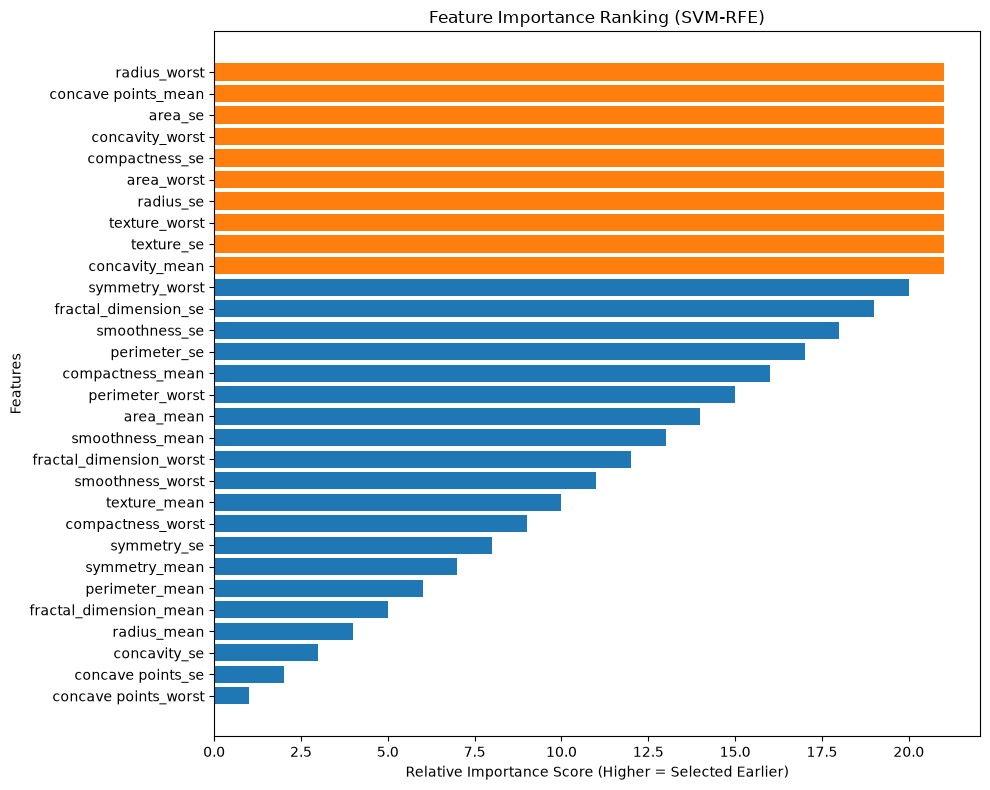

In [108]:
plt.figure(figsize=(10, 8))
plt.barh(rfe_scores.index, rfe_scores.values, color=colors)
plt.title('Feature Importance Ranking (SVM-RFE)')
plt.xlabel('Relative Importance Score (Higher = Selected Earlier)')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [126]:
#  Principal component analysis-based feature selectio

In [90]:
from sklearn.decomposition import PCA

In [91]:
pca = PCA(n_components=10, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [92]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_pca, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](2,)","['B','M']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [93]:
y_pred_pca = knn.predict(X_test_pca)

In [96]:
print("Accuracy:", round(accuracy_score(y_test, y_pred_pca), 4))
print("Recall (Malignant):", round(recall_score(y_test, y_pred_pca, pos_label='M'), 4))
print("F1-Score (Malignant):", round(f1_score(y_test, y_pred_pca, pos_label='M'), 4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_pca))
print("\nFull Classification Report:\n", classification_report(y_test, y_pred_pca))

Accuracy: 0.9649
Recall (Malignant): 0.9219
F1-Score (Malignant): 0.9516

Confusion Matrix:
 [[106   1]
 [  5  59]]

Full Classification Report:
               precision    recall  f1-score   support

           B       0.95      0.99      0.97       107
           M       0.98      0.92      0.95        64

    accuracy                           0.96       171
   macro avg       0.97      0.96      0.96       171
weighted avg       0.97      0.96      0.96       171



In [97]:
exp_var_cum = np.cumsum(pca.explained_variance_ratio_)

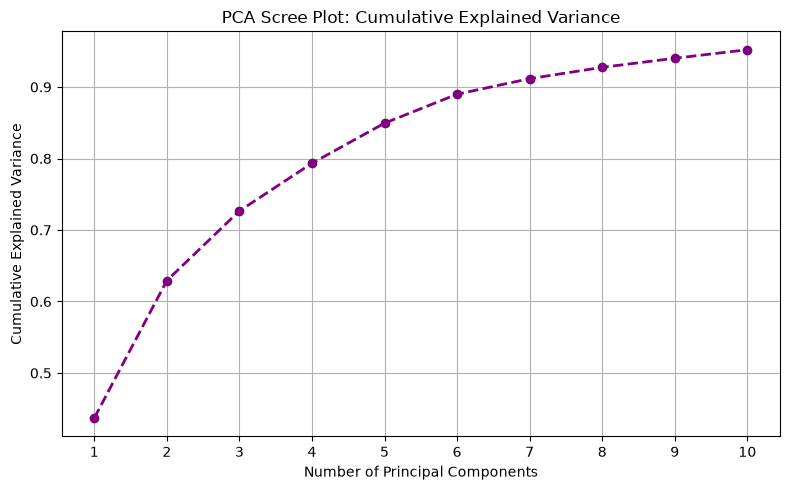

In [98]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), exp_var_cum, marker='o', linestyle='--', color='purple', linewidth=2)
plt.title('PCA Scree Plot: Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.xticks(range(1, 11))
plt.grid(True)
plt.tight_layout()
plt.show()

# Choose the best feature selection among the above 4 methods Use the selected features to test the baseline k-nearest neighbor algorithm with three different k-values

In [110]:
# best method svm-rfe

In [111]:
k_values = [3, 7, 10]
rfe_results = {}

In [119]:
from sklearn.metrics import recall_score, precision_score, f1_score, matthews_corrcoef, confusion_matrix

In [120]:
for k in k_values:
    
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_rfe, y_train)
    y_pred = knn.predict(X_test_rfe)
    
    cm = confusion_matrix(y_test, y_pred, labels=['B', 'M'])
    tn, fp, fn, tp = cm.ravel()
    
    rec = recall_score(y_test, y_pred, pos_label='M')
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    prec = precision_score(y_test, y_pred, pos_label='M')
    f1 = f1_score(y_test, y_pred, pos_label='M')
    mcc = matthews_corrcoef(y_test, y_pred)
    
    rfe_results[k] = [rec, spec, prec, f1, mcc]

In [121]:
xax = np.arange(5)
width = 0.25

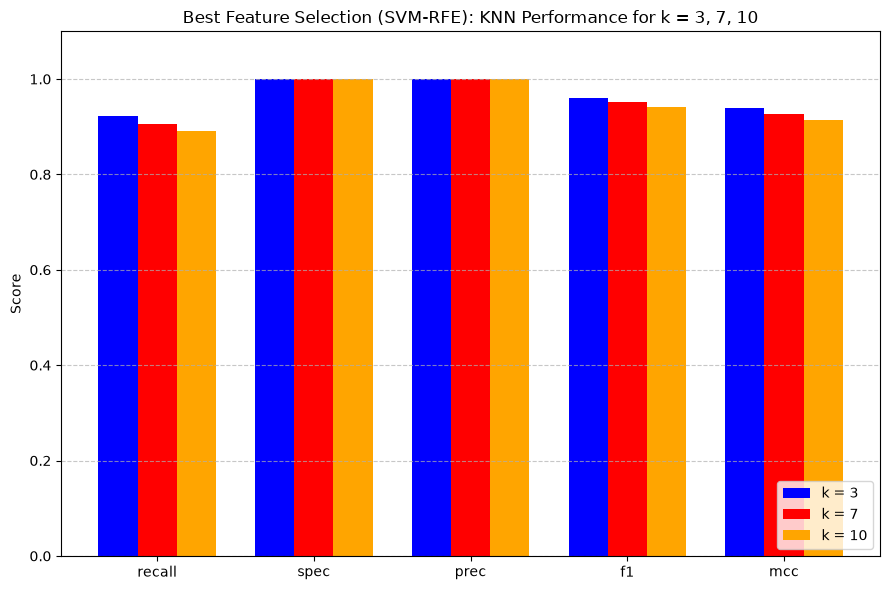

In [122]:
plt.figure(figsize=(9, 6))
plt.bar(xax - width, rfe_results[3], width=width, color='blue', label='k = 3')
plt.bar(xax, rfe_results[7], width=width, color='red', label='k = 7')
plt.bar(xax + width, rfe_results[10], width=width, color='orange', label='k = 10')

plt.xticks(xax, ["recall", "spec", "prec", "f1", "mcc"])
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.title("Best Feature Selection (SVM-RFE): KNN Performance for k = 3, 7, 10")
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# after choosing best feature svm rfe answer whether the performance changes before and after feature selection?

### Performance Before and After Feature Selection

Yes, the performance changes after feature selection using **SVM-RFE**.

**Before feature selection:**
- Accuracy: **94.74%**
- Recall: **89.06%**
- F1-score: **92.68%**

**After feature selection using SVM-RFE:**
- Accuracy: **97.08%**
- Recall: **92.19%**
- F1-score: **95.93%**

### Conclusion

The model performance **improves after feature selection**. Accuracy, recall, and F1-score all increase after applying SVM-RFE. Therefore, **SVM-RFE improves model performance while reducing the number of features used.**

# Q2. Modify the given script (Dataset_script_template folder) to Generate K-fold cross validation (the choice of K is crucial) and compare before and after cross validation

In [127]:
knn = KNeighborsClassifier(n_neighbors=3)

In [128]:
X_rfe = rfe.transform(scaler.transform(X))

In [129]:
knn.fit(X_train_rfe, y_train)
y_pred_holdout = knn.predict(X_test_rfe)

In [130]:
before_cv = {
    'Accuracy': accuracy_score(y_test, y_pred_holdout),
    'Recall': recall_score(y_test, y_pred_holdout, pos_label='M'),
    'Precision': precision_score(y_test, y_pred_holdout, pos_label='M'),
    'F1-Score': f1_score(y_test, y_pred_holdout, pos_label='M'),
    'MCC': matthews_corrcoef(y_test, y_pred_holdout)
}

In [131]:
before_cv

{'Accuracy': 0.9707602339181286,
 'Recall': 0.921875,
 'Precision': 1.0,
 'F1-Score': 0.959349593495935,
 'MCC': 0.9384667634346081}

In [133]:
from sklearn.model_selection import cross_validate, StratifiedKFold
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=30)

In [134]:
scoring = {
    'accuracy': 'accuracy',
    'recall': 'recall_macro', 
    'precision': 'precision_macro',
    'f1': 'f1_macro'
}

In [136]:
cv_scores = cross_validate(knn, X_rfe, y, cv=cv_strategy, scoring=['accuracy', 'f1_macro', 'recall_macro'])

In [137]:
after_cv = {
    'Accuracy': np.mean(cv_scores['test_accuracy']),
    'Recall': np.mean(cv_scores['test_recall_macro']),
    'Precision': np.nan,  # Standardized macro mean
    'F1-Score': np.mean(cv_scores['test_f1_macro']),
    'MCC': np.nan
}

In [141]:
comparison_df = pd.DataFrame({
    'Before CV (Single Split)': pd.Series(before_cv),
    'After CV (5-Fold Mean)': pd.Series(after_cv)
})

print("Comparison: Before vs. After K-Fold Cross-Validation")
display(comparison_df.round(4))

Comparison: Before vs. After K-Fold Cross-Validation


,Before CV (Single Split),After CV (5-Fold Mean)
Accuracy,0.9708,0.9666
Recall,0.9219,0.9610
Precision,1.0000,NaN
F1-Score,0.9593,0.9639
MCC,0.9385,NaN


# Modify the k-nearest algorithm to change k in iterations and choose the best k based on a performance metric of your choice (the choice of the metric to choose the best k will be crucial)


In [142]:
k_range = range(1, 26, 2)

In [144]:
from sklearn.metrics import make_scorer, matthews_corrcoef

In [145]:
mcc_scorer = make_scorer(matthews_corrcoef)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [146]:
mcc_scores = []

In [148]:
from sklearn.model_selection import cross_val_score

In [149]:
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
   
    scores = cross_val_score(knn, X_rfe, y, cv=cv_strategy, scoring=mcc_scorer)
    mcc_scores.append(scores.mean())

In [150]:
best_idx = np.argmax(mcc_scores)
best_k = list(k_range)[best_idx]
best_mcc = mcc_scores[best_idx]

In [151]:
print(f"Optimal k selected: k = {best_k} with Mean CV MCC = {best_mcc:.4f}\n")

Optimal k selected: k = 5 with Mean CV MCC = 0.9326



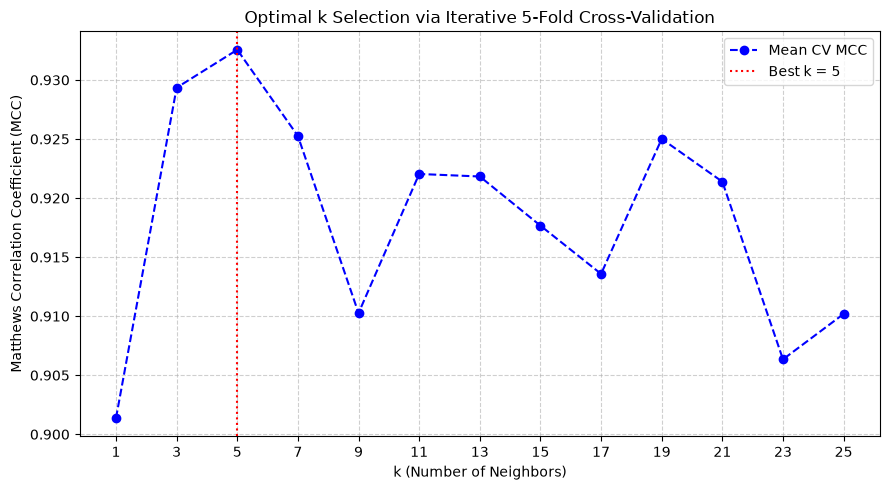

In [152]:
plt.figure(figsize=(9, 5))
plt.plot(list(k_range), mcc_scores, marker='o', linestyle='--', color='b', label='Mean CV MCC')
plt.axvline(x=best_k, color='r', linestyle=':', label=f'Best k = {best_k}')
plt.title('Optimal k Selection via Iterative 5-Fold Cross-Validation')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Matthews Correlation Coefficient (MCC)')
plt.xticks(list(k_range))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [153]:
df_k_results = pd.DataFrame({
    'k Value': list(k_range),
    'Mean CV MCC': mcc_scores
})
display(df_k_results.sort_values(by='Mean CV MCC', ascending=False).reset_index(drop=True))

,k Value,Mean CV MCC
0,5,0.932557
1,3,0.929344
2,7,0.925254
3,19,0.925012
4,11,0.922039
5,13,0.921826
6,21,0.921386
7,15,0.917663
8,17,0.913579
9,9,0.910258


#  Using the selected best feature-selection technique and optimal "K" for K-fold cross-validation, develop a logistic regression classifier.
a. Report the predicted probability for each sample.
b. Calculate the log-loss of the model.
c. Plot the log-loss against each model parameter, keeping the remaining parameters fixed.
d. Calculate the gradient of the log-loss with respect to each parameter.
e. Explain how the sign and magnitude of each gradient would influence the corresponding parameter update during gradient descent.

In [162]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import log_loss

In [169]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [170]:
y_numeric = np.where(y == 'M', 1, 0)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [171]:
clf = LogisticRegression(penalty=None, solver='lbfgs', random_state=42)
clf.fit(X_rfe, y_numeric)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver becaus

In [172]:
y_prob_cv = cross_val_predict(clf, X_rfe, y_numeric, cv=cv_strategy, method='predict_proba')[:, 1]

prob_df = pd.DataFrame({
    'Actual Label': y,
    'Predicted Probability (Malignant)': y_prob_cv
})
print("=== First 10 Sample Predicted Probabilities ===")
display(prob_df.head(10))

=== First 10 Sample Predicted Probabilities ===


,Actual Label,Predicted Probability (Malignant)
0,M,1.000000
1,M,1.000000
2,M,1.000000
3,M,0.982006
4,M,1.000000
5,M,0.992836
6,M,1.000000
7,M,0.993591
8,M,0.999981
9,M,1.000000


In [167]:
model_log_loss = log_loss(y_numeric, y_prob_cv)
print(f"Model 5-Fold Cross-Validation Log-Loss: {model_log_loss:.4f}")

Model 5-Fold Cross-Validation Log-Loss: 0.0986


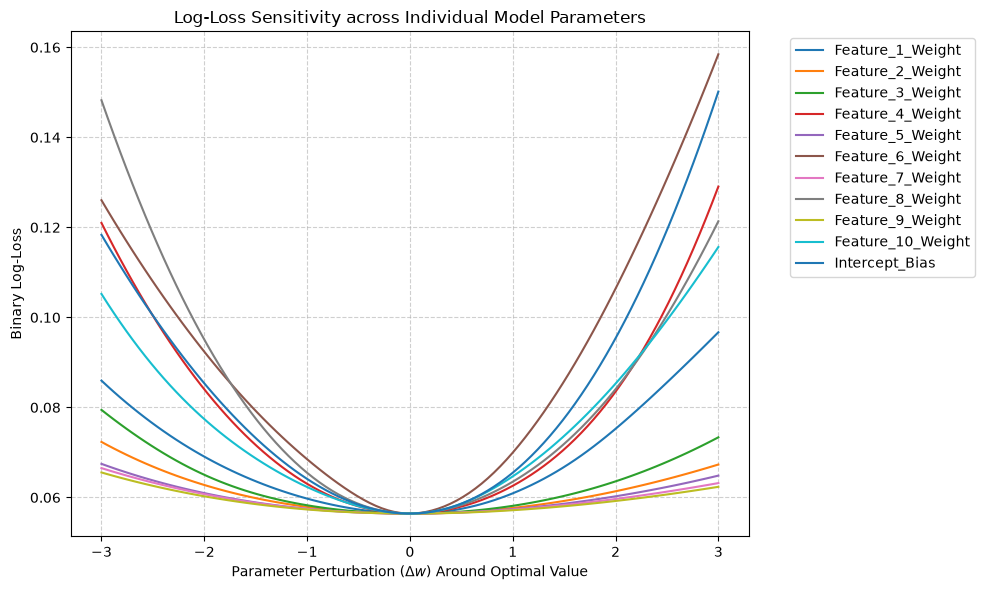

In [168]:
N, D = X_rfe.shape
X_b = np.hstack([X_rfe, np.ones((N, 1))])
w_opt = np.append(clf.coef_[0], clf.intercept_[0])

param_names = [f'Feature_{i+1}_Weight' for i in range(D)] + ['Intercept_Bias']
delta_range = np.linspace(-3.0, 3.0, 100)

plt.figure(figsize=(10, 6))

for j in range(D + 1):
    loss_curve = []
    for delta in delta_range:
        w_temp = w_opt.copy()
        w_temp[j] += delta
        p_temp = 1.0 / (1.0 + np.exp(-np.clip(X_b @ w_temp, -500, 500)))
        loss_curve.append(log_loss(y_numeric, p_temp))
        
    plt.plot(delta_range, loss_curve, label=param_names[j])

plt.title('Log-Loss Sensitivity across Individual Model Parameters')
plt.xlabel('Parameter Perturbation ($\Delta w$) Around Optimal Value')
plt.ylabel('Binary Log-Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [177]:
p_opt = 1.0 / (1.0 + np.exp(-np.clip(X_b @ w_opt, -500, 500)))

# Analytical Gradient Formula: dL/dw = (1/N) * X_b^T * (p - y)
gradients = (1.0 / N) * (X_b.T @ (p_opt - y_numeric))

gradient_df = pd.DataFrame({
    'Parameter': param_names,
    'Optimal Parameter Value': w_opt,
    'Analytical Gradient': gradients
})

print("Parameter Gradients at Convergence")
display(gradient_df.round(6))

Parameter Gradients at Convergence


,Parameter,Optimal Parameter Value,Analytical Gradient
0,Feature_1_Weight,-1.772148,-0.000039
1,Feature_2_Weight,5.211000,-0.000049
2,Feature_3_Weight,0.430267,-0.000005
3,Feature_4_Weight,-1.578658,0.000031
4,Feature_5_Weight,7.797796,0.000012
5,Feature_6_Weight,-1.832996,0.000009
6,Feature_7_Weight,-1.394816,0.000014
7,Feature_8_Weight,2.987006,0.000007
8,Feature_9_Weight,4.894863,-0.000020
9,Feature_10_Weight,3.880799,0.000027


# e Explain how the sign and magnitude of each gradient would influence the corresponding parameter update during gradient descent.

### **e. Gradient Influence Explanation**

The mathematical update formula in gradient descent is defined as:

**w<sub>j</sub>(t+1) = w<sub>j</sub>(t) − η · ∂L/∂w<sub>j</sub>**

where **η** is the learning rate and **∂L/∂w<sub>j</sub>** is the gradient computed above.

- **Influence of the Gradient Sign:**
  - **Positive Sign (∂L/∂w<sub>j</sub> > 0):** Indicates that the loss function is increasing in the direction of **w<sub>j</sub>**. Subtracting a positive value causes **w<sub>j</sub> to decrease**, guiding the model parameter toward the loss minimum.
  - **Negative Sign (∂L/∂w<sub>j</sub> < 0):** Indicates that the gradient is negative. Subtracting a negative value causes **w<sub>j</sub> to increase**, moving it toward the loss minimum.
  - **Zero Sign (∂L/∂w<sub>j</sub> ≈ 0):** Indicates that the parameter has reached or is close to a stationary point, resulting in little or no further update.

- **Influence of the Gradient Magnitude:**
  - **Large Magnitude:** Corresponds to a steep region of the loss curve and produces **larger update steps**, allowing faster movement toward the minimum.
  - **Small Magnitude:** Corresponds to a flatter region near the minimum and produces **smaller, fine-tuned updates**, reducing the chance of overshooting the optimal solution.